---
# <div align="center"><font color='blue'> COSC 2779/2972 | Deep Learning </font></div>
## <div align="center"><font color='blue'> Assignment 1: Introduction to Deep Convolutional Neural Networks</font></div>
### <div align="center">by Daniil Pkhakadze (s4101606) RMIT semester 2 2026</div>
---

## The problem.
A drone company (RedKite Aerospace) needs its drones to be able to read hand signals from the person receiving the drone delivery. Different gestures need to map to different commands and the drone needs to be able to differentiate
between them. A segmentor that already exists on the aircraft will cut the relevant parts out (the gestures) and pass each one to the model as 5 frames.
<br>
The task at hand is a **13-class classification problem** over these pre-segmented frames: 5 frames go into the model, and it outputs one label for the given gesture.
<br>
The 13 classes (gestures) that exist in the dataset are:
- `AllClear`
- `HaveCommand`
- `Hover`
- `Land`
- `LandingDirection`
- `MoveAhead`
- `MoveDownward`
- `MoveToLeft`
- `MoveToRight`
- `MoveUpward`
- `NotClear`
- `SlowDown`
- `WaveOff`
<br>
I will be building a classifier model. There are some restrictions: the computer is already overloaded as it is running navigation, mapping, comms etc., so there is very little space and power to run a complicated classifier model. Due to that, we are restricted to only use a 2-D convolutional backbone. The model also has to run inference on one instance at a time on an embedded board, which essentially means that it needs to stay small enough for real-time operation to be possible.
<br>
A 2-D CNN by itself would not be able to achieve satisfactory accuracy results on such a small dataset. Using an existing ImageNet-pretrained backbone could be a solution - that way the model doesn't have to learn all the visual features from scratch. We can also apply data augmentation, which would help us get more use out of the small dataset that we have.
<br>
Another potential architectural issue is that a 2-D CNN is only able to take 1 image as input to produce 1 output label, so normally it doesn't have a way to use the sequence of 5 frames that we have.
Getting the 5 frames into a 2-D CNN is an issue that will need to be addressed by attempting various appraoches to this problem.

1. **Singular frame** - classify simple based on one frame out of 5, which is the simplest possible approach. This will serve as the *baseline*.
2. **Early frame fusion** - we will stack the 5 frames into one as channels - this is a workaround for the network to get all 5 images in one input.
3. **Late frame fusion** - we will run the same backbone on each of the five frames in the sequence and then we will combine the resulting features in the head.
<br>
The given dataset itself could prove to be a problem - it was recorded with RedKite's own staff. On the actual day of the demo, a member of the client's staff will actually be doing the gestures for testing, which will be a person that the model has never seen before in an unseen location.

## Setup.
First, we need to import all the core libraries we will need for development. We will also be setting a fixed random seed to make sure our results are always reproducible.

In [2]:
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, models
from torch.utils.data import DataLoader, Dataset, Subset
import matplotlib.pyplot as plt
import numpy as np
import os
from pathlib import Path
from collections import Counter
from PIL import Image


SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## Step 1. Load the dataset.
We will define a "Dataset" class for PyTorch to load our image data. Each training example is a folder containing 5 frames:
- `__getitem__` loads the 5 frames, then applies the tranform to each one and then puts them into one tensor.
Source is the Week 4 Lab.

In [3]:

class GestureDataset(Dataset):
    def __init__(self, instances, labels, transform=None):
        self.instances = instances
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        inst_dir = self.instances[idx][0]
        label = self.labels[idx]

        frame_files = sorted(os.listdir(inst_dir))
        frames = []
        for fname in frame_files:
            img = Image.open(os.path.join(inst_dir, fname))
            if self.transform is not None:
                img = self.transform(img)
            frames.append(img)
        frames = torch.stack(frames)

        return frames, label

First, let's setup the data folder and create a list of all the 13 gesture classes. Also we will create a dictionary that maps each class name to an integer index for simplicity.

In [4]:
DATA_FOLDER = 'data_resized'

CLASS_NAMES = ['AllClear', 'HaveCommand', 'Hover', 'Land', 'LandingDirection',
               'MoveAhead', 'MoveDownward', 'MoveToLeft', 'MoveToRight',
               'MoveUpward', 'NotClear', 'SlowDown', 'WaveOff']
NUM_CLASSES = len(CLASS_NAMES)

class_to_index = {}
for i in range (NUM_CLASSES):
    class_to_index[CLASS_NAMES[i]] = i

We will now inspect the folder structure. For each out of the 13 index classes and each subject (S) within, every `InstanceN` folder will be a singular training example (since it contains a single gesture with 5 frames). We need to store information, such as the path, subject number and the class label.
This is based on code from Week 6 lab, except data from this dataset goes one folder deeper since it is organized like so: *class -> subject -> instance*.

In [5]:
for cls in CLASS_NAMES:
    cls_dir = os.path.join(DATA_FOLDER, cls)
    print(f'{cls}:')
    for subj in sorted(os.listdir(cls_dir)):
        subj_dir = os.path.join(cls_dir, subj)
        n = 0
        if os.path.isdir(subj_dir):
            for inst in os.listdir(subj_dir):
                if os.path.isdir(os.path.join(subj_dir, inst)):
                    n+=1
            print(f'  {subj}: {n}')
    print()

AllClear:
  S1: 8
  S11: 9
  S12: 8
  S13: 4
  S14: 10
  S15: 7
  S3: 9
  S4: 7
  S5: 6
  S6: 9
  S9: 10

HaveCommand:
  S1: 9
  S11: 7
  S12: 7
  S13: 9
  S14: 8
  S15: 9
  S3: 10
  S4: 7
  S5: 5
  S6: 5
  S9: 9

Hover:
  S1: 9
  S11: 9
  S12: 11
  S13: 11
  S4: 13
  S5: 16
  S6: 13

Land:
  S1: 17
  S11: 19
  S12: 18
  S13: 18
  S4: 17
  S5: 17
  S6: 16

LandingDirection:
  S1: 7
  S11: 9
  S12: 8
  S13: 8
  S4: 7
  S5: 4
  S6: 5

MoveAhead:
  S1: 10
  S11: 8
  S12: 10
  S13: 9
  S14: 8
  S15: 10
  S3: 10
  S4: 6
  S5: 8
  S6: 10
  S9: 10

MoveDownward:
  S1: 8
  S11: 5
  S12: 8
  S13: 5
  S4: 7
  S5: 6
  S6: 7

MoveToLeft:
  S1: 9
  S11: 9
  S12: 8
  S13: 9
  S14: 9
  S15: 9
  S3: 10
  S4: 7
  S5: 7
  S6: 8
  S9: 10

MoveToRight:
  S1: 9
  S11: 8
  S12: 9
  S13: 8
  S14: 8
  S15: 9
  S3: 9
  S4: 10
  S5: 6
  S6: 9
  S9: 10

MoveUpward:
  S1: 10
  S11: 9
  S12: 9
  S13: 10
  S4: 8
  S5: 7
  S6: 9

NotClear:
  S1: 5
  S11: 9
  S12: 7
  S13: 9
  S14: 10
  S15: 9
  S3: 10
  S4: 6
  S5: 

As we can see, the subject IDs are S1 to S15, however only 11 of them are actually present in the dataset - S2, S7, S8, S10 are the ones NOT present. In the context of this dataset a subject is a unique person.
We can also see that not each one of the 11 subjects has performed every single one of the 13 gestures:
- 7 gestures done by all 11 people
- 6 gestures were however only done by 7 people (`Hover`, `Land`, `LandingDirection`, `MoveDownward`, `MoveUpward`, `WaveOff`). 4 people that did NOT do the gesture are S3, S9, S14, S15.
The amount of instances for each subject within a gesture folder is also uneven - for example many subjects for the `Land` gesture have up to 19 instancesm while some other ones only have as low as 5 instances for a subject (for example `SlowDown`).
Even without a graph we can see that there is significant class imbalance that we will need to address. It will be addressed later when we are choosing a performance measure and splitting the data.

### Step 2. Exploratory Data Analysis (EDA).
Now we need to look at the data that we have.
Starting with class distributions - we should see how many instances there are for each gesture present in the dataset. As mentioned above, we already know that there is imbalance per subject.

In [6]:
instances = list()
subjects = list()
for cls in CLASS_NAMES:
    cls_dir = os.path.join(DATA_FOLDER, cls)
    for subj in sorted(os.listdir(cls_dir)):
            subj_dir = os.path.join(cls_dir, subj)
            if os.path.isdir(subj_dir):
                for inst in sorted(os.listdir(subj_dir)):
                    inst_dir = os.path.join(subj_dir, inst)
                    if os.path.isdir(inst_dir):
                        instances.append((inst_dir, class_to_index[cls]))
                        subjects.append(subj)
                    
print(f"Num instances: {len(instances)}")
print(f"Num subjects: {len(set(subjects))}")


Num instances: 1059
Num subjects: 11


In total there are 1059 instances across 11 subjects (different people), where one instance is one gesture performance which consists of 5 frames.
We can already conclute that this dataset is *small* for a deep learning model. Overfitting will likely be a significant problem.

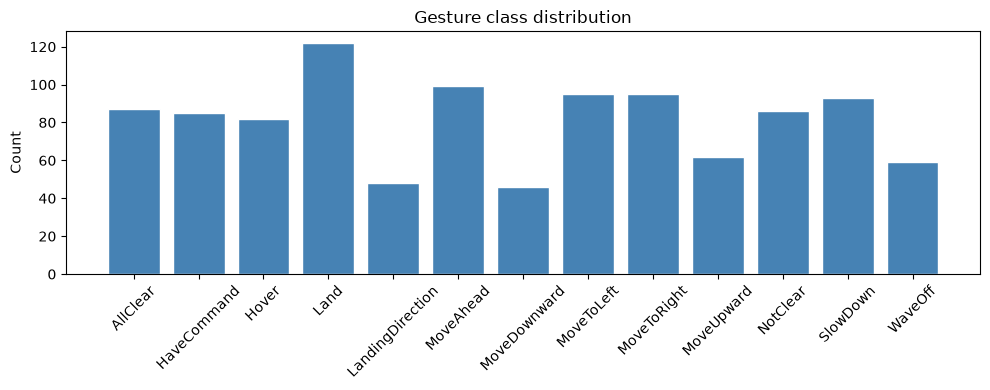

In [7]:
from collections import Counter

labels = [label for _, label in instances]
counts = Counter(labels)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar([CLASS_NAMES[k] for k in sorted(counts)],
       [counts[k] for k in sorted(counts)],
       color='steelblue', edgecolor='white')
ax.set_title('Gesture class distribution')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

This is a bar plot of total numbers of all instances for each gesture across all subjects.
As we can obviously see in the chart, the imbalance we expected before is confirmed: `Land` is the largest class with 120+ instances and `MoveDownward` is the smallest with ~45 instances.
The smallest class is around 2.5x smaller than the largest which is a noticeable and significant imbalance.
Most gestures have an average of around 80-90 instances.

It is also typically useful to get random samples of the data and view it. We will inspect real frames now.
We will depict all 5 frames for several instances. This will let us see if the images are clear or noisy as well as if we can see obvious movement across the 5 frames.

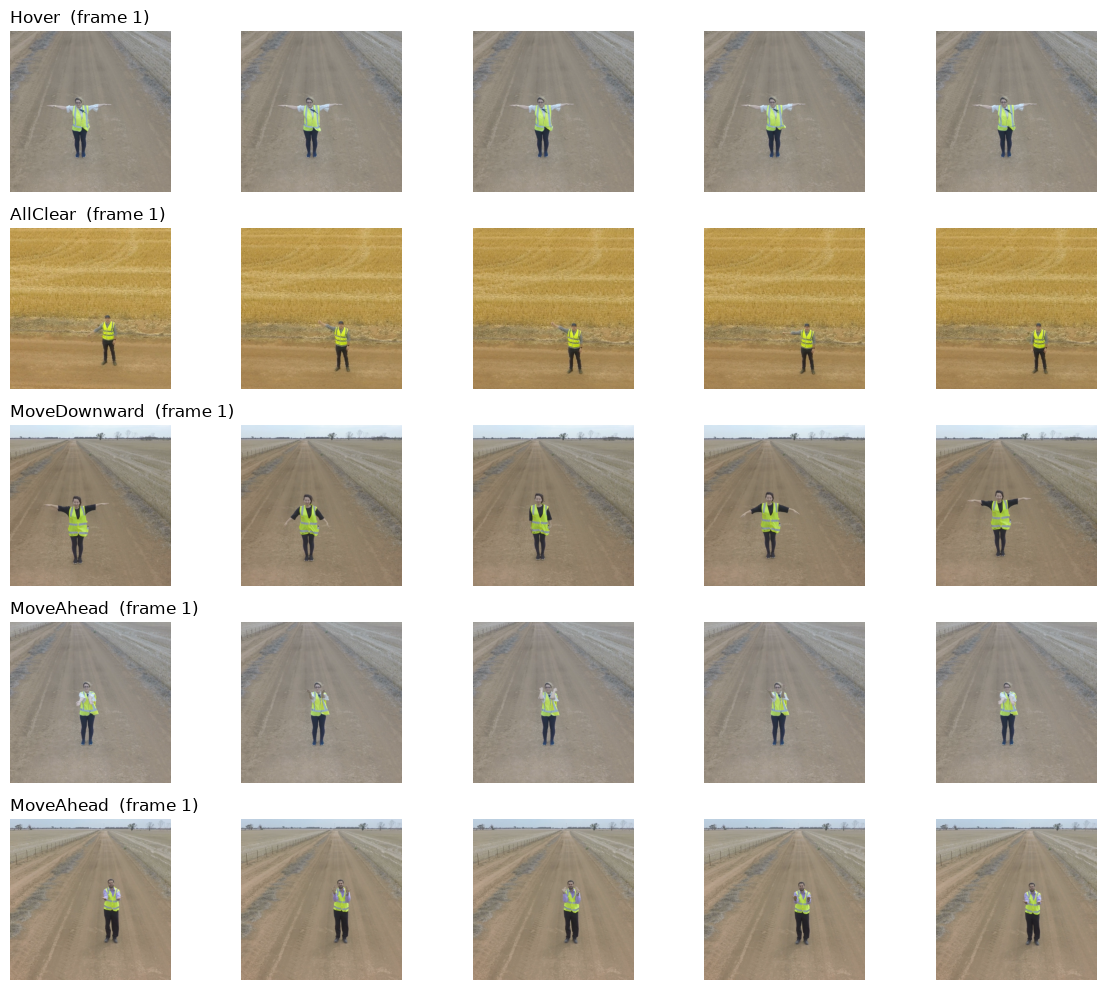

In [8]:
import random
from PIL import Image

random.seed(SEED)
sample_idxs = random.sample(range(len(instances)), 5)

fig, axes = plt.subplots(5, 5, figsize=(12, 10))
for row, idx in enumerate(sample_idxs):
    inst_dir, label = instances[idx]
    frame_files = sorted(f for f in os.listdir(inst_dir)
                         if f.endswith(('.jpg', '.jpeg', '.png')))
    for col, fname in enumerate(frame_files):
        img = Image.open(os.path.join(inst_dir, fname)).convert('RGB')
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_ylabel(CLASS_NAMES[label])
    axes[row, 0].set_title(f'{CLASS_NAMES[label]}  (frame 1)', loc='left')
plt.tight_layout()
plt.show()

For some of the gestures, such as `MoveDownward`, show very clear and obvious movement across the 5 frames.
<br>
However `Hover` shows 0 movement, which makes sense, since the gesture IS holding your arms still signalling the drone to also stay still.
<br>
Other gestures, for example `MoveAhead` do show movement across the 5 frames, but it's rather difficult to see due to quality issues and the nature of the gesture, which includes subtle hand movements.
<br>
We can also notice that there are multiple frames in different gestures that are very ambiguous. Several different gestures have a frame where the person has his arms out stretched out to the sides. This is a good indicator that the **single frame** approach would not be satisfactory for this problem - it would be impossible for the model to tell between different gestures if they have very similar frames.
<br>
There are also some obvious quality issues that are visible to the human eye: people are at different distances from the camera between various instances - sometimes they're very close, sometimes so far that you can't really make out the gestures. The gestures can also look quite different at different scales. Many of the frames are also blurry. Both of these are good reasons to implement augmentation to make sure that the model is able to differentiate between gestures at different scales (which is also necessary for the demo day).

It is also worth to verify our assumption that every instance does actually have strictly 5 frames.

In [9]:
five = 0
not_five = 0

for inst_dir, _ in instances:
    n = 0
    for f in os.listdir(inst_dir):
        if f.endswith(('.jpg', '.jpeg', '.png')):
            n += 1
    if n == 5:
        five += 1
    else:
        not_five += 1

print(f'Instances with 5 frames: {five}')
print(f'Other: {not_five}')

Instances with 5 frames: 1059
Other: 0


The assumption is correct - every single instance has strictly 5 frames.

Another thing that is important to verify is to see whether all of the images are already resized to be the exact same size/resolution.

In [10]:

sizes = []
for inst_dir, _ in instances:
    frame_files = os.listdir(inst_dir)
    for f in frame_files:
        img = Image.open(os.path.join(inst_dir, f))
        sizes.append(img.size)

print('frame sizes:', Counter(sizes))

frame sizes: Counter({(512, 512): 5295})


Great, all 5295 images are uniform in size, being 512x512 pixels. No need to worry about handling different resolutions.

### Step 3. Performance target and measure

We need to decide on the performance measure prior to building the models. We can also set a realistic target that we expect to hit for this dataset and chosen performance measure.

Since there is a moderate to significant class imbalance, **accuracy** is not the best performance measure for this dataset. If accuracy is chosen, the model would be biased towards the larger classes, since the model would just be able to always predict the majority classes and receive a decently high accuracy. All the 13 gestures are equally important, so we need a different performance meaure, which does not discriminate across minority classes.
<br>
We will proceed with **macro-averaged F1 scores**. This metric averages the F1 scores across the 13 gestures, which gives each one an equal weight, regardless of the amount of instances for it.

The task is getting the model to differentiate across 13 different gestures after training on a small dataset of 1059 instances, which were recorded in-house by the company staff and not expert signallers. The model will have to also be evaluated on a person that was never seen by it, which is rather difficult. The model will need to be able to generalize its predictions to a new face, rather than just memorizing the 11 different subjects (people) that exist in the dataset.
<br>
**The bottom line**: randomly guessing across 13 different classes would be: 100/13 = 7.69% accuracy. So at THE VERY LEAST the model has to beat that in order for us to conclude that it has learnt at least something useful.
<br>
That being said, we want a decently high prediction success rate, but due to a limited sized dataset with quite low-quality pictures, a 70-80% macro-F1 on unseen data would be a reasonable performance target.
<br><br>
We will need to be smart about splitting the data - we only have 11 people available. The model will be tested on a completely new unseen person. To handle that, we will need to not train the model on instances from several specific subjects, so they can act as preivously unseen people.

### Step 4. Data splitting

A typical approach is splitting data 60/20/20 randomly into train, validation and test sets.
<br>
Specifically in this case, that is not a good approach. That way the same subject could potentially end up in both training and test sets. This way the model would get really good test scores by recognizing the same people it has already encountered in the training, instead of focusing on the gestures.
This would likely result in a failure during the demo day - the model is tested on someone completely new, so if the model encounters all 11 subjects during the training, none of them would be unseen.
<br>
To handle this, we won't be randomly splitting the data. Instead, we will split by subjects. Some people will be only in the training set, some only in validation and some in the test set. This way, no people will be appearing in more than one split.
That will allow the scores we get in testing and validation to measure what is actually relevant to us - how well does the model detect gestures from people it has never ever seen before.

Before actually splitting, we should look at how many instances come from each subject. It would be smart to pick the subjects with the most instances for the training set, since once a person is held out for a specific set, all the instances (gestures) that that person performed are also allocated to that set.

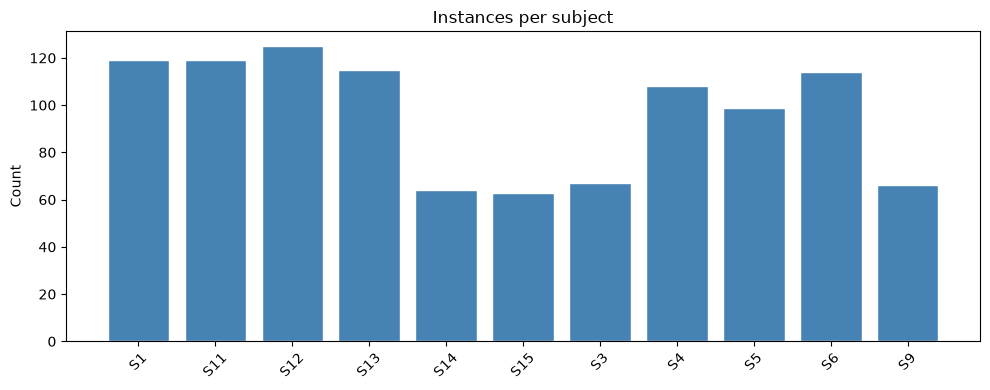

Counter({'S12': 125, 'S1': 119, 'S11': 119, 'S13': 115, 'S6': 114, 'S4': 108, 'S5': 99, 'S3': 67, 'S9': 66, 'S14': 64, 'S15': 63})


In [11]:
subj_counts = Counter(subjects)

plt.figure(figsize=(10, 4))
plt.bar(subj_counts.keys(), subj_counts.values(), color='steelblue', edgecolor='white')
plt.title('Instances per subject')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(subj_counts)

S1, S11, S12, S13, S4 and S6 all have 100+ instances each, while S14, S15, S3 and S5 have less than 100 (most of these have aroun 60-70).
<br>
Even though we want to save subjects with most instances for the training set, we need to make sure we cover all 13 gestures in each (val, train and test) set.

We know from before that 4 of the subjects did not perform all 13 gestures, so we need to be smart about out split.

In [15]:
import pandas as pd

gestures = [CLASS_NAMES[label] for _, label in instances]

table = pd.crosstab(pd.Series(subjects, name='Subject'), pd.Series(gestures, name='Gesture'))

table


Gesture,AllClear,HaveCommand,Hover,Land,LandingDirection,MoveAhead,MoveDownward,MoveToLeft,MoveToRight,MoveUpward,NotClear,SlowDown,WaveOff
Subject,,,,,,,,,,,,,
S1,8,9,9,17,7,10,8,9,9,10,5,9,9
S11,9,7,9,19,9,8,5,9,8,9,9,9,9
S12,8,7,11,18,8,10,8,8,9,9,7,10,12
S13,4,9,11,18,8,9,5,9,8,10,9,7,8
S14,10,8,0,0,0,8,0,9,8,0,10,11,0
S15,7,9,0,0,0,10,0,9,9,0,9,10,0
S3,9,10,0,0,0,10,0,10,9,0,10,9,0
S4,7,7,13,17,7,6,7,7,10,8,6,6,7
S5,6,5,16,17,4,8,6,7,6,7,6,5,6


This table shows and confirms the previous concerns - 6/13 gestures (Hover, Land, LandingDirection, MoveDownward, MoveUpward and WaveOff) were all only performed by 7/11 available people.

Since 6/13 gestures can only be gotten from 7 subjects, each split has to include at least some of those subjects, since we need to make sure each split has examples of all gestures to make sure the model is trained for AND tested on all of the gestures.
<br>
We need to make sure the training set gets every gesture, as well as the validation and test sets.

So, based on the table and graph above, we will be splitting the data by subject:

- **Test set:** S6 (13 gestures), S13 (13 gestures)
- **Validation set:** S4 (13 gestures), S9 (7 gestures)
- **Training set:** S1 (13 gestures), S11 (13 gestures), S12 (13 gestures), S5 (13 gestures), S3 (7 gestures), S14 (7 gestures), S15 (7 gestures)

This way all three sets see each of the 13 gestures and 4/7 subjects that did all gestures are in the training set, providing it plenty of data to train on.

It is worth noting that with such a split, it's reasonable to assume that the model will perform worse on the 6 gestures that weren't performed by every subject compared to the other 7, since those 6 gestures are only trained on 4 subjects instead of 7 (like the other gestures).

In [20]:
TEST_SUBJ = ['S6', 'S13']
VAL_SUBJ = ['S4', 'S9']

train_instances = []
test_instances = []
val_instances = []

for i in range (len(instances)):
    subject = subjects[i]
    if subject in TEST_SUBJ:
        test_instances.append(i)
    elif subject in VAL_SUBJ:
        val_instances.append(i)
    else:
        train_instances.append(i)
        

print(f"Training set: {len(train_instances)} instances")
print(f"Testing set: {len(test_instances)} instances")
print(f"Validation set: {len(val_instances)} instances")
print(f"Total instances: {len(instances)}")


Training set: 656 instances
Testing set: 229 instances
Validation set: 174 instances
Total instances: 1059


In [21]:
print(656/1059)
print(229/1059)
print(174/1059)

0.619452313503305
0.21624173748819642
0.1643059490084986


This way we get 656 instances in the **training** set (~62% of the dataset), 229 in the **testing** set (~22%) and 174 in the **validation** set (~16%), resulting in a 62/16/22 split.
<br>We have successfully split the data in a way, where each of the 13 gestures is present in each of the three splits.

### Step 5. Transforms and preprocessing

We need to turn the raw frames into tensors that a model can actually use. We have to take multiple steps:
1) First, resize each image to 224x224. Currently our frames are all 512x512, however the ImageNet-pretrained ResNet was trained on 224x224 inputs and therefore performs best on them, which means we have to size down our images. Furthermore, this will make the model lighter due to less computation being needed, which is good, since the model has to be quick enough to run in real-time on the drone.
2) Convert to tensor. We need to convert all the images into PyTorch tensors.
3) Since due to a small and lackluster dataset we are relying on a pretrained backbone, the inputs need to be normalized or otherwise the pretrained weights won't be able to see the input that they actually expect.
<br>
We will start off by doing the same transforms on all 3 splits *without* adding augmentation, which can be later added in the optimization step.

In [23]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

base_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])